# Rock-Paper-Scissors CNN (PyTorch)

Gesture classification **rock / paper / scissors / nothing** on the dataset [Anirudha Bhagwat (Kaggle)](https://www.kaggle.com/datasets/anirudhabhagwat/rock-paper-scissors-images).

## 1. Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import json
import random
from pathlib import Path

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

VAL_RATIO = 0.15
TEST_RATIO = 0.15
NUM_WORKERS = 0
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
def set_seed(seed) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

## 2. Dataset Overview

In [3]:
class_names = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

counts = {name: len(list((DATA_DIR / name).glob("*.*"))) for name in class_names}
total_images = sum(counts.values())

print("Classes:", class_names)
print("Number of images per class:")
for name in class_names:
    print(f"  {name:10s}: {counts[name]:4d}")
print(f"Total: {total_images}")

Classes: ['nothing', 'paper', 'rock', 'scissors']
Number of images per class:
  nothing   : 2100
  paper     : 1640
  rock      : 2040
  scissors  : 1712
Total: 7492


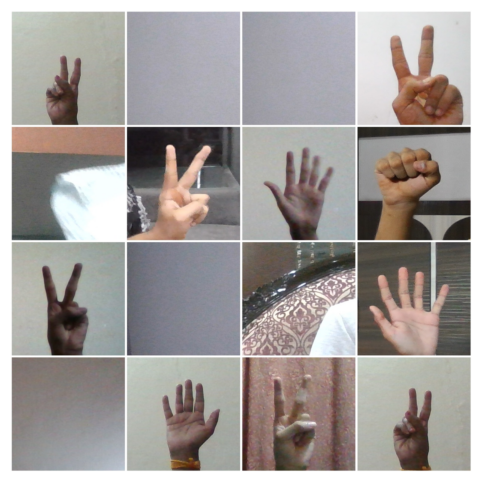

In [4]:
preview_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

preview_dataset = datasets.ImageFolder(DATA_DIR, transform=preview_transform)
images, labels = next(iter(DataLoader(preview_dataset, batch_size=16, shuffle=True)))

grid = make_grid(images, nrow=4, normalize=True, pad_value=1)
plt.figure(figsize=(10, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.show()

## 3. Data Loading and Preprocessing

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_eval_dataset = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

dataset_size = len(full_dataset)
test_size = int(TEST_RATIO * dataset_size)
val_size = int(VAL_RATIO * dataset_size)
train_size = dataset_size - val_size - test_size

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices, test_indices = random_split(
    range(dataset_size),
    [train_size, val_size, test_size],
    generator=generator,
)


class SubsetDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, eval_dataset, indices):
        self.base_dataset = base_dataset
        self.eval_dataset = eval_dataset
        self.indices = list(indices)
        self.use_eval = False

    def set_eval_mode(self, enabled: bool) -> None:
        self.use_eval = enabled

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        dataset = self.eval_dataset if self.use_eval else self.base_dataset
        return dataset[real_idx]


train_dataset = SubsetDataset(full_dataset, full_eval_dataset, train_indices)
val_dataset = SubsetDataset(full_dataset, full_eval_dataset, val_indices)
test_dataset = SubsetDataset(full_dataset, full_eval_dataset, test_indices)
val_dataset.set_eval_mode(True)
test_dataset.set_eval_mode(True)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 5246 | Val: 1123 | Test: 1123


## 4. Defining the CNN Architecture

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, pool: bool = True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class RPSClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
            ConvBlock(256, 512, pool=False),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = RPSClassifier(num_classes=len(class_names)).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {num_params:,}")

RPSClassifier(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

## 5. Training the Model

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

model.load_state_dict(best_state)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

torch.save(
    {
        "model_state_dict": best_state,
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "img_size": IMG_SIZE,
        "val_acc": best_val_acc,
    },
    OUTPUT_DIR / "rps_cnn_best.pt",
)
print(f"PyTorch checkpoint saved to {OUTPUT_DIR / 'rps_cnn_best.pt'}")

Epoch 01/10 | train loss: 0.8903, acc: 0.6332 | val loss: 0.4643, acc: 0.8468
Epoch 02/10 | train loss: 0.4133, acc: 0.8553 | val loss: 0.2065, acc: 0.9394
Epoch 03/10 | train loss: 0.2386, acc: 0.9197 | val loss: 0.1040, acc: 0.9795
Epoch 04/10 | train loss: 0.1642, acc: 0.9472 | val loss: 0.0381, acc: 0.9964
Epoch 05/10 | train loss: 0.1138, acc: 0.9638 | val loss: 0.0402, acc: 0.9938
Epoch 06/10 | train loss: 0.0978, acc: 0.9676 | val loss: 0.0205, acc: 0.9947
Epoch 07/10 | train loss: 0.0783, acc: 0.9750 | val loss: 0.0159, acc: 0.9973
Epoch 08/10 | train loss: 0.0661, acc: 0.9783 | val loss: 0.0088, acc: 1.0000
Epoch 09/10 | train loss: 0.0452, acc: 0.9865 | val loss: 0.0113, acc: 0.9991
Epoch 10/10 | train loss: 0.0621, acc: 0.9800 | val loss: 0.0047, acc: 1.0000

Best validation accuracy: 1.0000
PyTorch checkpoint saved to outputs\rps_cnn_best.pt


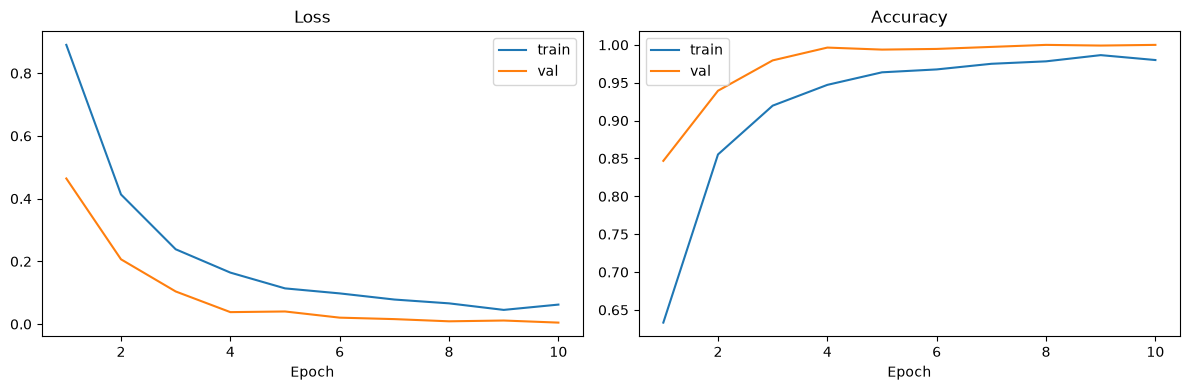

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluation

Test accuracy: 0.9982

Confusion matrix (rows=true, cols=pred):
[[334   0   0   0]
 [  0 254   0   1]
 [  0   0 302   0]
 [  0   0   1 231]]


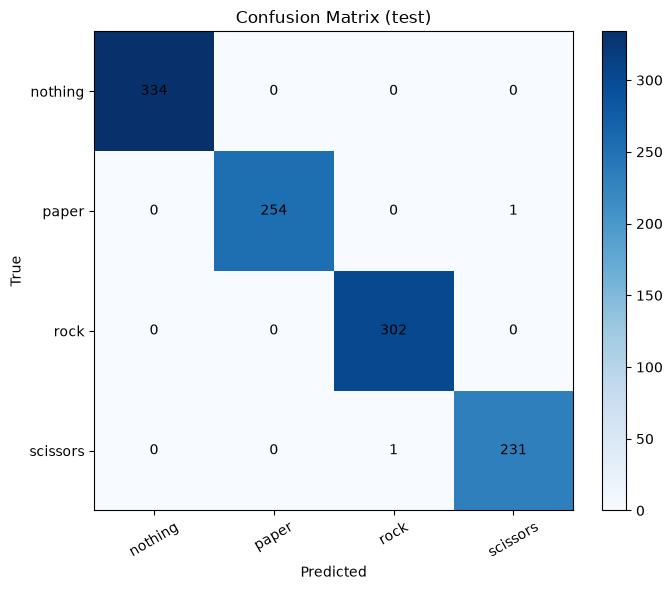

  nothing   : 1.0000
  paper     : 0.9961
  rock      : 1.0000
  scissors  : 0.9957


In [9]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


y_true, y_pred = evaluate(model, test_loader)
test_acc = (y_true == y_pred).mean()
print(f"Test accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_true, y_pred, len(class_names))
print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=30)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (test)")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
for name, acc in zip(class_names, per_class_acc):
    print(f"  {name:10s}: {acc:.4f}")

## 7. Exporting the Model to ONNX

In [10]:
ONNX_PATH = OUTPUT_DIR / "rps_cnn.onnx"

model.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"},
    },
)

metadata = {
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE,
    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225],
    },
    "test_accuracy": float(test_acc),
    "best_val_accuracy": float(best_val_acc),
}

with open(OUTPUT_DIR / "rps_cnn_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"ONNX model saved to {ONNX_PATH}")
print(f"Metadata saved to {OUTPUT_DIR / 'rps_cnn_metadata.json'}")

ONNX model saved to outputs\rps_cnn.onnx
Metadata saved to outputs\rps_cnn_metadata.json
